In [1]:
# Install required packages (run once)
# pip install tensorflow scikit-learn matplotlib numpy
# Already installed? Skip this cell.
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "scikit-learn", "matplotlib", "numpy", "-q"])

0

# Fashion-MNIST — CNN Classification

We compare two architecturally distinct CNNs:
- **Architecture 1 — Small CNN**: 2 convolutional blocks (8, 16 filters), direct Flatten → Output
- **Architecture 2 — Deep CNN**: 3 convolutional blocks (32, 64, 128 filters) + dense head (256 units), BatchNorm, Dropout

Each architecture is tested with and without regularisation, and with Early Stopping.

### Imports

In [2]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
%matplotlib inline

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import (Input, Conv2D, Dense, Dropout,
                                      Flatten, MaxPool2D, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.random import set_seed

print("Tensorflow version " + tf.__version__)

Tensorflow version 2.20.0


### Data loading & preprocessing

In [3]:
batch_size  = 128
classes     = 10
epochs      = 100

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test  = X_test.reshape(X_test.shape[0],   28, 28, 1).astype('float32') / 255
input_shape = (28, 28, 1)

Y_train = to_categorical(y_train, classes)
Y_test  = to_categorical(y_test,  classes)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)


### Visualise samples

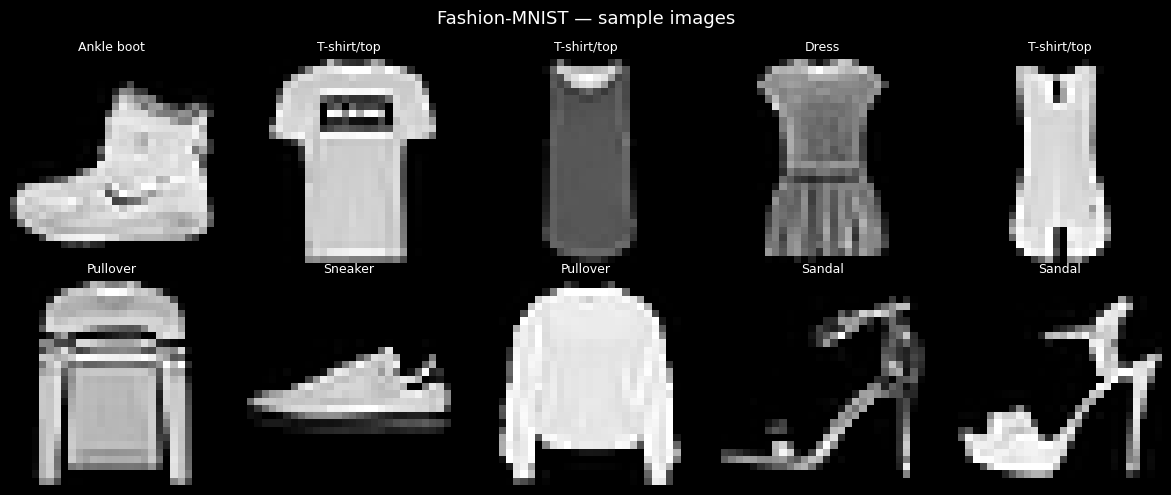

In [4]:
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion-MNIST — sample images', fontsize=13)
plt.tight_layout()
plt.show()

### Helper functions

In [5]:
def plot_history(hs, epochs, metric):
    plt.style.use('dark_background')
    plt.rcParams['figure.figsize'] = [15, 8]
    plt.rcParams['font.size'] = 16
    plt.clf()
    for label, hist in hs.items():
        plt.plot(hist.history[metric],
                 label=f'{label} train {metric}', linewidth=2)
        plt.plot(hist.history[f'val_{metric}'],
                 label=f'{label} val {metric}', linewidth=2)
    x_ticks = np.arange(0, epochs + 1, max(1, epochs // 10))
    x_ticks[0] += 1
    plt.xticks(x_ticks)
    plt.ylim((0, 1))
    plt.xlabel('Epochs')
    plt.ylabel('Loss' if metric == 'loss' else 'Accuracy')
    plt.legend()
    plt.show()


def plot_confusion_matrix(model, title='Confusion Matrix'):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def clean_up(model):
    K.clear_session()
    del model
    gc.collect()

---
## Architecture 1 — Small CNN

```
Input(28,28,1)
  → Conv2D(8, 3×3, ReLU) → MaxPool(2×2)
  → Conv2D(16, 3×3, ReLU) → MaxPool(2×2)
  → Flatten → Output(10, softmax)
```

Lightweight model. Two experiments: **no dropout** vs **dropout=0.2**.

In [6]:
def build_small_cnn(dropout=False):
    np.random.seed(1402)
    set_seed(1981)

    inp = Input(shape=input_shape, name='Input')
    x = Conv2D(8,  (3,3), padding='same', activation='relu', name='Conv2D-1')(inp)
    x = MaxPool2D((2,2), name='MaxPool-1')(x)
    if dropout:
        x = Dropout(0.2, name='Drop-1')(x)
    x = Conv2D(16, (3,3), padding='same', activation='relu', name='Conv2D-2')(x)
    x = MaxPool2D((2,2), name='MaxPool-2')(x)
    if dropout:
        x = Dropout(0.2, name='Drop-2')(x)
    x = Flatten(name='Flatten')(x)
    out = Dense(classes, activation='softmax', name='Output')(x)
    return Model(inputs=inp, outputs=out)


def train(model, optimizer, epochs, batch_size, callbacks=None, verbose=0):
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy', metrics=['accuracy'])
    hs = model.fit(X_train, Y_train, validation_split=0.1,
                   epochs=epochs, batch_size=batch_size,
                   callbacks=callbacks, verbose=verbose)
    print('Finished training.')
    print('------------------')
    model.summary()
    return hs

### Small CNN — Experiment 1a: No dropout

Finished training.
------------------


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D-1 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool-1 (MaxPooling2D)        │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D-2 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool-2 (MaxPooling2D)        │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,296 (106.63 KB)

 Trainable params: 9,098 (35.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,198 (71.09 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8966 - loss: 0.3411

Test Acc: 0.89660  Test Loss: 0.34106


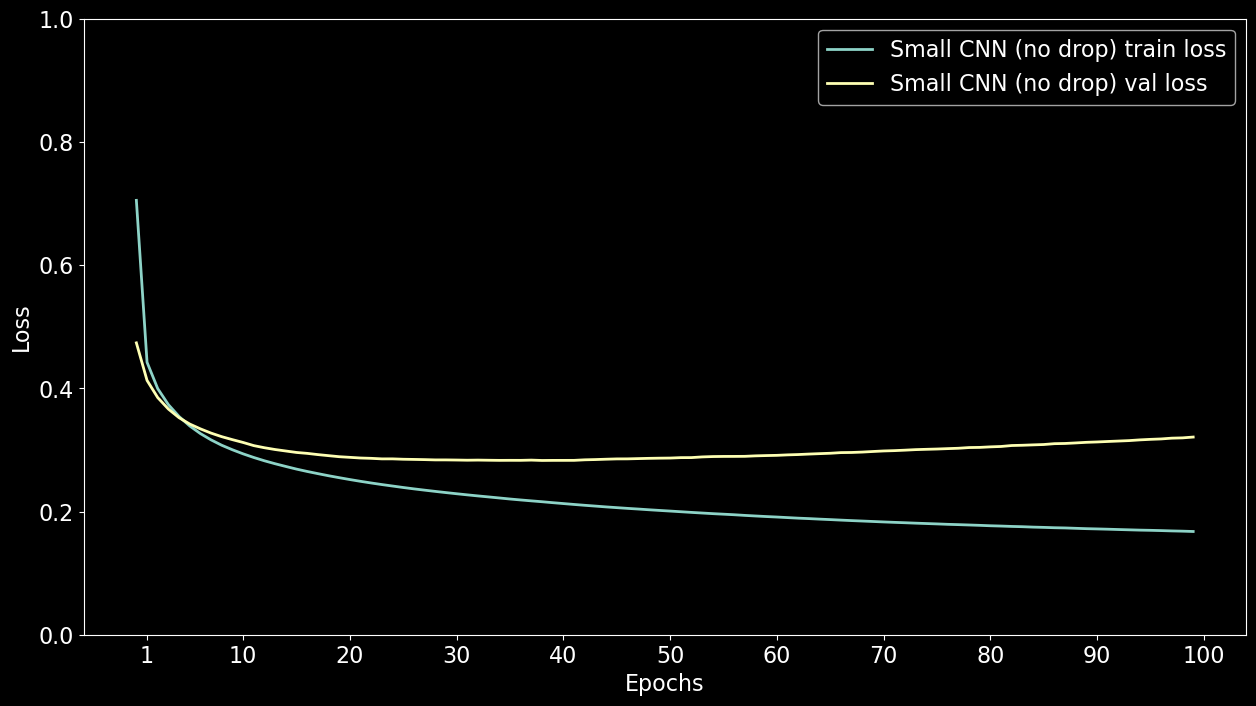

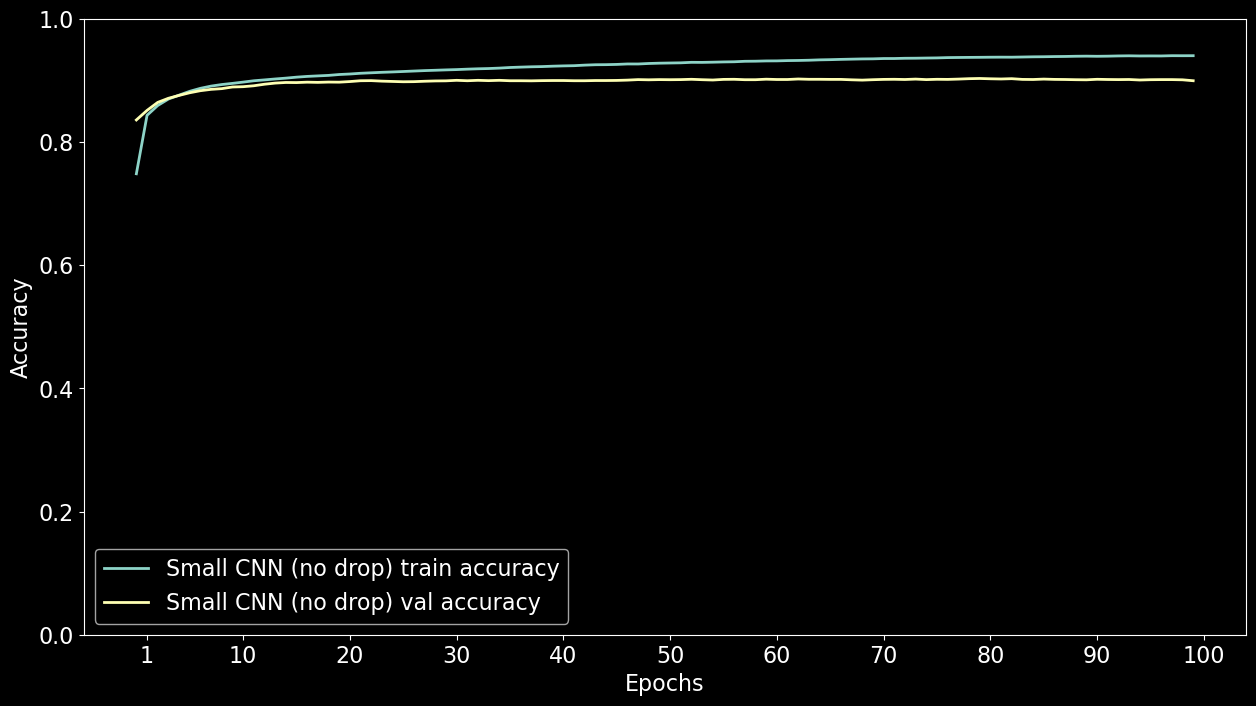

In [7]:
small_base = build_small_cnn(dropout=False)
small_base_hs = train(small_base, Adam(), epochs, batch_size)
small_base_eval = small_base.evaluate(X_test, Y_test, verbose=1)

print(f"\nTest Acc: {small_base_eval[1]:.5f}  Test Loss: {small_base_eval[0]:.5f}")
plot_history({'Small CNN (no drop)': small_base_hs}, epochs, 'loss')
plot_history({'Small CNN (no drop)': small_base_hs}, epochs, 'accuracy')

clean_up(small_base)

### Small CNN — Experiment 1b: Dropout 0.2 + Early Stopping

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7300 - loss: 0.7697 - val_accuracy: 0.8297 - val_loss: 0.4753
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8285 - loss: 0.4793 - val_accuracy: 0.8553 - val_loss: 0.4112
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8440 - loss: 0.4374 - val_accuracy: 0.8648 - val_loss: 0.3870
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8552 - loss: 0.4105 - val_accuracy: 0.8717 - val_loss: 0.3637
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8615 - loss: 0.3942 - val_accuracy: 0.8745 - val_loss: 0.3515
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8659 - loss: 0.3789 - val_accuracy: 0.8762 - val_loss: 0.3443
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8709 - loss: 0.3674 - val_accuracy: 0.8833 - val_loss: 0.3284
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8727 - loss: 0.3580 - 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D-1 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool-1 (MaxPooling2D)        │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop-1 (Dropout)                │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D-2 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool-2 (MaxPooling2D)        │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Drop-2 (Dropout)                │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,296 (106.63 KB)

 Trainable params: 9,098 (35.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,198 (71.09 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9005 - loss: 0.2733

Stopped @ epoch 53
Test Acc: 0.90050  Test Loss: 0.27332


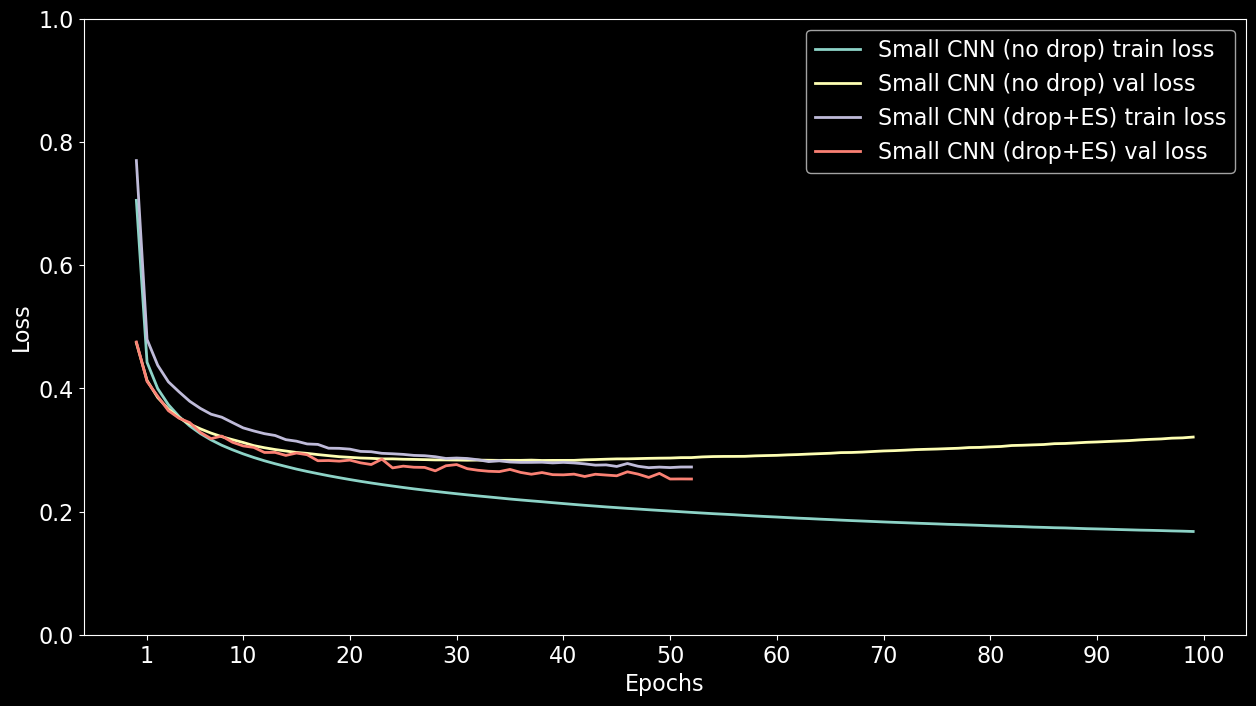

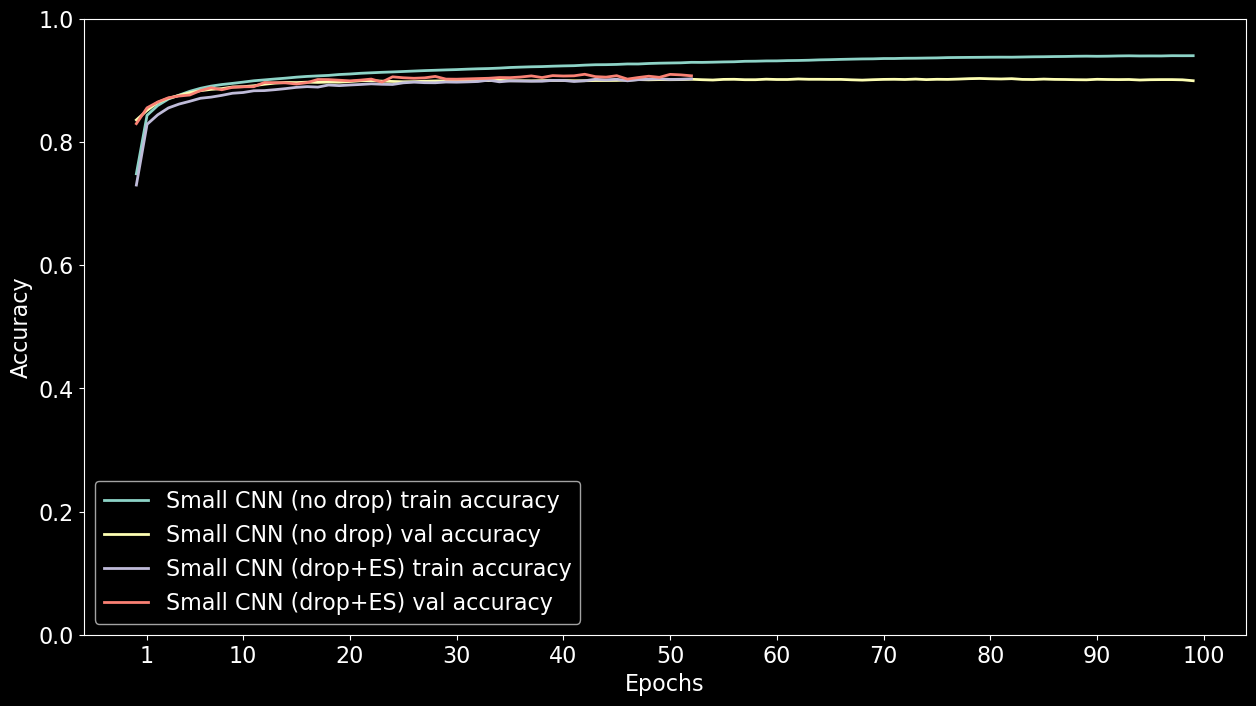

In [8]:
es = EarlyStopping(monitor='val_accuracy', patience=10,
                   verbose=1, restore_best_weights=True)

small_reg = build_small_cnn(dropout=True)
small_reg_hs = train(small_reg, Adam(), epochs, batch_size,
                     callbacks=[es], verbose=1)
small_reg_eval = small_reg.evaluate(X_test, Y_test, verbose=1)

ep = len(small_reg_hs.history['loss'])
print(f"\nStopped @ epoch {ep}")
print(f"Test Acc: {small_reg_eval[1]:.5f}  Test Loss: {small_reg_eval[0]:.5f}")
plot_history({'Small CNN (no drop)': small_base_hs,
              'Small CNN (drop+ES)':  small_reg_hs}, epochs, 'loss')
plot_history({'Small CNN (no drop)': small_base_hs,
              'Small CNN (drop+ES)':  small_reg_hs}, epochs, 'accuracy')

clean_up(small_reg)

---
## Architecture 2 — Deep CNN

```
Input(28,28,1)
  → Conv2D(32, 3×3, ReLU) → BN → MaxPool(2×2) → Dropout(0.2)
  → Conv2D(64, 3×3, ReLU) → BN → MaxPool(2×2) → Dropout(0.2)
  → Conv2D(128,3×3, ReLU) → BN → MaxPool(2×2) → Dropout(0.2)
  → Flatten → Dense(256, ReLU) → Dropout(0.3) → Output(10, softmax)
```

Deeper architecture with more filters and a dedicated dense classification head.
Two experiments: **no regularisation (BN only)** vs **full regularisation (BN + Dropout + ES)**.

In [9]:
def build_deep_cnn(dropout=False, batchnorm=True):
    np.random.seed(1402)
    set_seed(1981)

    inp = Input(shape=input_shape, name='Input')
    x = inp
    for i, filters in enumerate([32, 64, 128]):
        x = Conv2D(filters, (3,3), padding='same',
                   activation='relu', name=f'Conv2D-{i+1}')(x)
        if batchnorm:
            x = BatchNormalization(name=f'BN-{i+1}')(x)
        x = MaxPool2D((2,2), name=f'MaxPool-{i+1}')(x)
        if dropout:
            x = Dropout(0.2, name=f'Drop-{i+1}')(x)

    x = Flatten(name='Flatten')(x)
    x = Dense(256, activation='relu', name='FC-1')(x)
    if dropout:
        x = Dropout(0.3, name='Drop-FC')(x)
    out = Dense(classes, activation='softmax', name='Output')(x)
    return Model(inputs=inp, outputs=out)

### Deep CNN — Experiment 2a: BatchNorm only (no dropout)

In [10]:
deep_base = build_deep_cnn(dropout=False, batchnorm=True)
deep_base_hs = train(deep_base, Adam(), epochs, batch_size)
deep_base_eval = deep_base.evaluate(X_test, Y_test, verbose=1)

print(f"\nTest Acc: {deep_base_eval[1]:.5f}  Test Loss: {deep_base_eval[0]:.5f}")
plot_history({'Deep CNN (BN only)': deep_base_hs}, epochs, 'loss')
plot_history({'Deep CNN (BN only)': deep_base_hs}, epochs, 'accuracy')

clean_up(deep_base)

KeyboardInterrupt: 

### Deep CNN — Experiment 2b: BatchNorm + Dropout + Early Stopping

In [ ]:
es = EarlyStopping(monitor='val_accuracy', patience=10,
                   verbose=1, restore_best_weights=True)

deep_reg = build_deep_cnn(dropout=True, batchnorm=True)
deep_reg_hs = train(deep_reg, Adam(), epochs, batch_size,
                    callbacks=[es], verbose=1)
deep_reg_eval = deep_reg.evaluate(X_test, Y_test, verbose=1)

ep = len(deep_reg_hs.history['loss'])
print(f"\nStopped @ epoch {ep}")
print(f"Test Acc: {deep_reg_eval[1]:.5f}  Test Loss: {deep_reg_eval[0]:.5f}")
plot_history({'Deep CNN (BN only)':       deep_base_hs,
              'Deep CNN (BN+Drop+ES)':    deep_reg_hs}, epochs, 'loss')
plot_history({'Deep CNN (BN only)':       deep_base_hs,
              'Deep CNN (BN+Drop+ES)':    deep_reg_hs}, epochs, 'accuracy')

### Confusion matrix — best model (Deep CNN regularised)

In [ ]:
plot_confusion_matrix(deep_reg, title='Confusion Matrix — Deep CNN (BN + Dropout + ES)')
clean_up(deep_reg)

---
## Final comparison — all CNN experiments

In [ ]:
print(f"{'Model':<40} {'Test Acc':>10} {'Test Loss':>12}")
print('-' * 64)
rows = [
    ('Small CNN (no dropout)',           small_base_eval),
    ('Small CNN (Dropout 0.2 + ES)',     small_reg_eval),
    ('Deep CNN  (BN only)',              deep_base_eval),
    ('Deep CNN  (BN + Dropout + ES)',    deep_reg_eval),
]
for name, ev in rows:
    print(f"{name:<40} {ev[1]:>10.5f} {ev[0]:>12.5f}")